# T6 · When PINNs fail — a catalogue, measured

The previous five notebooks built PINNs up. This one is the part an interview
actually probes: **when does this not work, and how would you know?**

Every number here was measured in this repository, on real data, with the
seed discipline stated: tune on 3/7/19, report on 11/23/42, never select on a
reported seed.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

import pandas as pd
from physprior.io import load_table
from physprior.reporting import conclusions as C

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


## 0 · The two shapes a PINN comes in

Before the failures, the anatomy. These are not variants of one architecture
— they answer different questions, and `w_phys` means something different in
each.

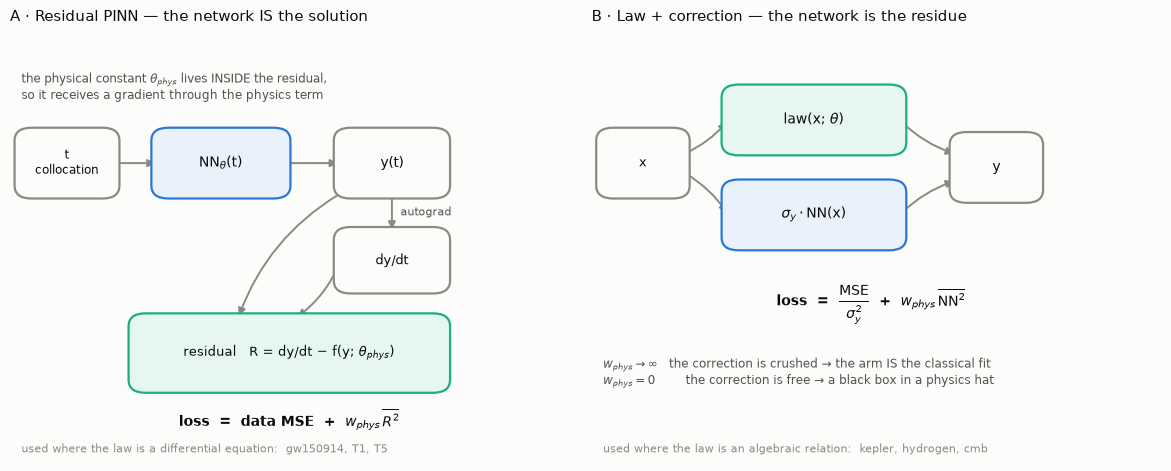

In [2]:
P.fig_pinn_anatomy(); plt.show()

Panel **A** is T1, T4 and T5: the law is a differential equation, the network
*is* the solution, and the physical constant sits inside the residual so it
receives a gradient through the physics term. Panel **B** is T3: the law is an
algebraic relation, the network is a *correction* to it, and `w_phys` is a
continuous dial between the classical fit and a black box.

## 1 · The network eats the physics if you let it

Already seen in T2 and T3 — repeated because it is the one that produces
*publishable-looking* wrong answers.

| problem | constant | error at `w_phys = 0` | error at `w_phys ≥ 0.01` |
|---|---|---|---|
| gravity | `GM_sun` | **19.5 %** | 0.005 % |
| quantum | `T_CMB` | **1.33 %** | 0.017 % |

Held-out error barely moves across that range. **A PINN that fits well is not
thereby measuring anything.**

## 2 · Fit quality cannot diagnose a wrong law

T4's post-Newtonian ablation: the chirp mass moves by 9 M☉ across truncation
orders while the RMSE hardly notices. If your model-selection criterion is
held-out error, you will select the wrong physics.

## 3 · A result still moving with step size is not a result

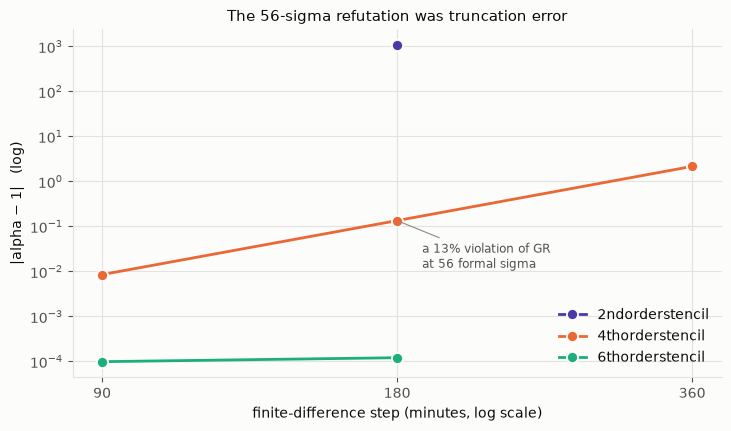

In [3]:
gr = load_table("relativity/mercury", "gr_convergence")
P.fig_alpha_convergence(gr.to_dict("records")); plt.show()

At a 3-hour step with a 4th-order stencil, the GR coefficient comes out at
**α = 1.1343 ± 0.0024** — a 13.4% violation of general relativity at **56
formal sigma**. It is entirely finite-difference truncation error. With a
6th-order stencil α agrees with Einstein to one part in 10⁴.

The error bar was never wrong. It was correctly answering a question about
the *statistics* of a model that was *systematically* wrong.

> The result is not α; it is α once it has stopped moving.

## 4 · Which switches actually help — measured, not assumed

Seven common PINN improvements were ablated one at a time on the tuning
seeds. The pre-registered ranking got the top two backwards.

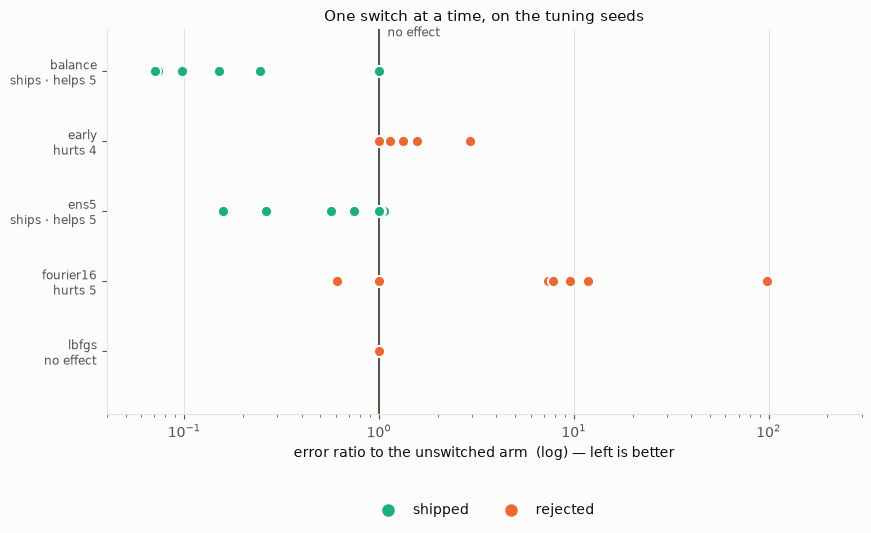

In [4]:
import glob
from physprior.benchmark.ablation import summarise
abl = pd.concat([pd.read_csv(f) for f in glob.glob("results/*/*/tune/ablation.csv")])
P.fig_ablation_effect(summarise(abl)); plt.show()

Every dot is one (track, protocol question). Left of the line the switch
helped, right of it it hurt, and the distance is the effect size on a log
scale. Two clusters entirely on one side, two entirely on the other, and one
sitting exactly on the line.

And what the shipped switch bought, per track, on the reporting seeds after
re-running the whole pipeline:

In [5]:
from IPython.display import HTML, display
display(HTML('<img src="../../figures/phase2_improvement.png" width="800">'))

| option | verdict |
|---|---|
| **gradient-norm loss balancing** (Wang et al. 2021) | **ships** — helps 5 cells, hurts none, up to 101× |
| deep ensembles | helps, but 5× the compute for a further 1.3–1.4× |
| **early stopping** | **rejected** — hurt 4 cells, helped none |
| **Fourier features** | **rejected** — made one track **98× worse** |
| **L-BFGS refinement** | **rejected** — its proposal never lowered the loss |

Two things worth saying out loud in an interview:

* Fourier features are the standard remedy for the spectral bias of T5 — and
  on *these* tracks, whose targets are smooth, they were catastrophic. A
  remedy is only a remedy for the disease it treats.
* The pre-registered ranking in `docs/plans/PLAN.md` put early stopping first
  and balancing fourth. The ablation reversed them. The ranking was left in
  the document rather than quietly reordered.

## 5 · Where the prior pays, and where it does not

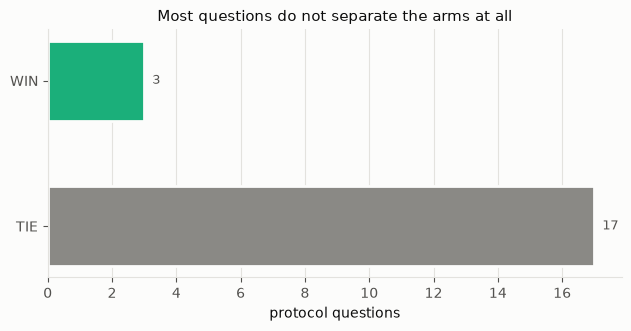

17 of 20 questions sit inside the seed spread


In [6]:
frame = C.verdict_frame("all")
counts = frame.verdict.str.split(" ").str[0].value_counts()
fig, ax = plt.subplots(figsize=(6.2, 3.2))
colours = {"WIN": P.ARM_COLOR["pinn"], "TIE": P.INK_MUTED}
ax.barh(list(counts.index), list(counts.values),
        color=[colours.get(k, P.INK_MUTED) for k in counts.index],
        edgecolor=P.SURFACE, linewidth=2, height=0.55)
for k, v in counts.items():
    ax.annotate(f"  {v}", xy=(v, k), va="center", fontsize=9, color=P.INK_2)
ax.set_xlabel("protocol questions"); ax.grid(axis="y", visible=False)
ax.set_title("Most questions do not separate the arms at all")
plt.show()
print(f"{counts.get('TIE', 0)} of {len(frame)} questions sit inside the seed spread")

Read the `verdict` column carefully. Most questions are **ties** — the gap
between arms is smaller than the seed-to-seed spread, and calling those wins
would be noise-mining.

The pattern across this repository, stated plainly:

1. **Inside the training range, with enough clean data, a tuned black box is
   competitive.** A physics prior buys little there. Claims to the contrary
   usually compare against an untuned baseline.
2. **Outside it the gap is orders of magnitude — but the mechanism is
   identifiability, not the mere presence of a law.** On `quantum/cmb`,
   out-of-band error falls ~56× as the fitted band reaches the Rayleigh-Jeans
   regime *while in-band error gets worse*. On `relativity/gw150914` —
   the counter-control — extrapolation from four faint cycles defeats every
   fitted arm, physics included.
3. **Only the physics arms return something a physicist can argue with**, and
   three times here the argument was worth having: QED in hydrogen, the PN
   expansion in GW150914, and a truncation error masquerading as a refutation
   of general relativity.

## The one-sentence version

> A physics prior buys extrapolation when the data can identify its
> parameters, and costs you accuracy when it cannot — and the only way to
> know which case you are in is to measure it against a control.

---

### Where to go next

* [`docs/gravity/`](../../docs/gravity) · [`docs/relativity/`](../../docs/relativity) · [`docs/quantum/`](../../docs/quantum) — the three problems in full
* [`docs/METHOD.md`](../../docs/METHOD.md) — the decisions, including the ones made *after* something went wrong
* [`docs/TOOLING.md`](../../docs/TOOLING.md) — how a formula comes out of symbolic regression